### Imports

In [160]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

### Loading Dataset

In [161]:
data_path = Path('data/raw/fake_job_postings.csv')
df_source = pd.read_csv(data_path)
df = df_source.copy(deep=True)

print(df.shape)
print(df.info())
print(df.describe())
print(df.columns.tolist())


(17880, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  obje

The dataset has 17,880 rows and 18 columns.

The columns are job_id, title, location, department, salary_range, company_profile, description, requirements, benefits, telecommuting, has_company_logo, has_questions, employment_type, required_experience, required_education, industry, function, fraudulent.

There are 5 numerical int64 columns (job_id, telecommuting, has_company_logo, has_questions, fraudulent), while the rest are text str columns.

In [162]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


### Data Cleaning

This section serves to clean the dataset by handling inconsistencies in strings, null or empty values, etc.


In [163]:
df.isnull().sum().sort_values(ascending=False)


salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
title                      0
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
fraudulent                 0
dtype: int64

In [164]:
df.isnull().mean() * 100

job_id                  0.000000
title                   0.000000
location                1.935123
department             64.580537
salary_range           83.959732
company_profile        18.501119
description             0.005593
requirements           15.078300
benefits               40.335570
telecommuting           0.000000
has_company_logo        0.000000
has_questions           0.000000
employment_type        19.412752
required_experience    39.429530
required_education     45.329978
industry               27.421700
function               36.101790
fraudulent              0.000000
dtype: float64

Given that salary range has 84.0% missing values and department has 64.5% missing values, can consider dropping these features since they are too sparse to extract meaning.
Perhaps can transform salary_range to salary_provided boolean column instead.

In [165]:
placeholders = ['n/a', 'na', 'none', 'null', '-', '?', 'not specified', 'unknown', 'other']
for col in df.select_dtypes(include='object').columns:
    mask = df[col].str.strip().str.lower().isin(placeholders)
    count = mask.sum()
    if count > 0:
        print(f"column name({col}): {count} placeholder values")
        print(df[col][mask].value_counts())
        print('\n')

column name(department): 2 placeholder values
department
Unknown    1
Other      1
Name: count, dtype: int64


column name(benefits): 1 placeholder values
benefits
na    1
Name: count, dtype: int64


column name(employment_type): 227 placeholder values
employment_type
Other    227
Name: count, dtype: int64


column name(function): 325 placeholder values
function
Other    325
Name: count, dtype: int64




In [166]:
df['benefits'] = df['benefits'].replace('na', np.nan)
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
str_cols =  ['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
num_cols = ['job_id', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']
text_cols = ['company_profile', 'description', 'requirements', 'benefits']
cat_cols = ['location', 'employment_type', 'required_experience', 
            'required_education', 'industry', 'function']
binary_cols = ['telecommuting', 'has_company_logo', 'has_questions']
target = 'fraudulent'
to_drop = ['job_id', 'department', 'salary_range']

df[text_cols] = df[text_cols].fillna('')
df[cat_cols] = df[cat_cols].fillna('Not Provided')

df.isnull().sum()

job_id                     0
title                      0
location                   0
department             11553
salary_range           15012
company_profile            0
description                0
requirements               0
benefits                   0
telecommuting              0
has_company_logo           0
has_questions              0
employment_type            0
required_experience        0
required_education         0
industry                   0
function                   0
fraudulent                 0
dtype: int64

We will drop job_id column as ids do not have any predictice power over whether selected job is fradulent

In [167]:
df = df.drop(['job_id'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17880 non-null  object
 2   department           6327 non-null   object
 3   salary_range         2868 non-null   object
 4   company_profile      17880 non-null  object
 5   description          17880 non-null  object
 6   requirements         17880 non-null  object
 7   benefits             17880 non-null  object
 8   telecommuting        17880 non-null  int64 
 9   has_company_logo     17880 non-null  int64 
 10  has_questions        17880 non-null  int64 
 11  employment_type      17880 non-null  object
 12  required_experience  17880 non-null  object
 13  required_education   17880 non-null  object
 14  industry             17880 non-null  object
 15  function             17880 non-null  object
 16  frau

given that the location column can be split into `country`, `state`, `city`, We will create 3 additional columns country, state and city.

In [168]:
df['location'].head()
df[["country","state","city"]] = df["location"].str.split(",", n=2, expand=True)

#top 5 countries
df["country"].value_counts().head(5)

country
US    10656
GB     2384
GR      940
CA      457
DE      383
Name: count, dtype: int64

we count the number of values with missing states or cities.

In [169]:
df[["state", "city"]].isna().sum()

state    440
city     440
dtype: int64

In [170]:
df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,country,state,city
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,Other,Internship,Not Provided,Not Provided,Marketing,0,US,NY,New York
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,Not Provided,Marketing and Advertising,Customer Service,0,NZ,,Auckland
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,0,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,0,US,IA,Wever
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,US,DC,Washington
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,US,FL,Fort Worth


### Exploratory Data Analysis (EDA)

This section serves to conduct exploratory data analysis on the dataset.

## Univariate analysis

### Numerical Column Analysis 

Analyze the distributions and spread of numerical data in the numerical data columns.

In [171]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
telecommuting,17880.0,0.042897,0.202631,0.0,0.0,0.0,0.0,1.0
has_company_logo,17880.0,0.795302,0.403492,0.0,1.0,1.0,1.0,1.0
has_questions,17880.0,0.491723,0.499945,0.0,0.0,0.0,1.0,1.0
fraudulent,17880.0,0.048434,0.214688,0.0,0.0,0.0,0.0,1.0


Only telecommuting , has_company_logo, has_questions and fradulent columns are numeric and since we have dropped the job_id column, these four are the only columns we can statistical description of its data spread.


Telecommuting distribution:
telecommuting
0    95.710291
1     4.289709
Name: proportion, dtype: float64


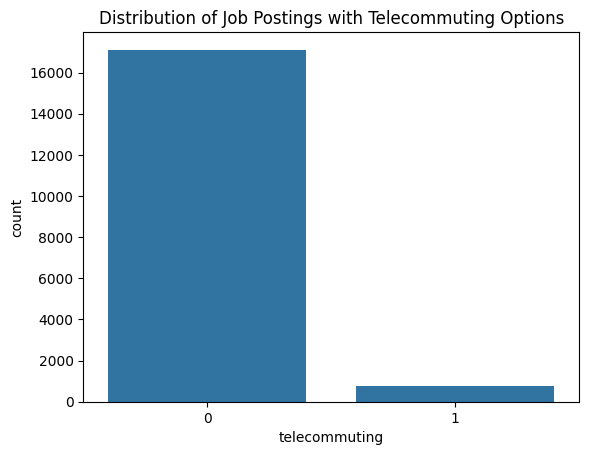

In [172]:
print("\nTelecommuting distribution:")
print(df['telecommuting'].value_counts(normalize=True) * 100)

sns.countplot(x=df['telecommuting'])
plt.title('Distribution of Job Postings with Telecommuting Options')
plt.show()

we can see that most jobs do not involve telecommunting


Has Company Logo distribution:
has_company_logo
1    79.530201
0    20.469799
Name: proportion, dtype: float64


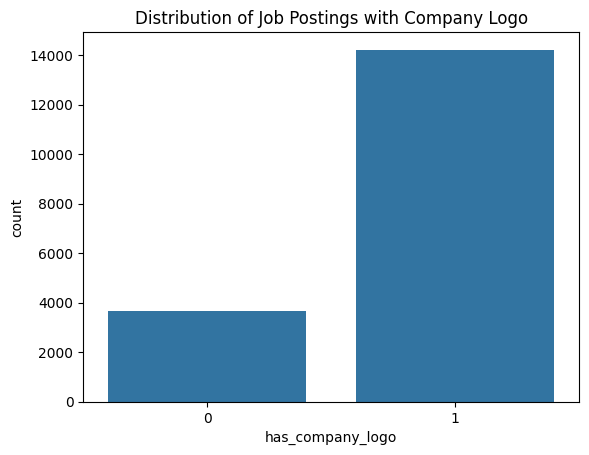

In [173]:
print("\nHas Company Logo distribution:")
print(df['has_company_logo'].value_counts(normalize=True) * 100)

sns.countplot(x=df['has_company_logo'])
plt.title('Distribution of Job Postings with Company Logo')
plt.show()

Majority of job posting do have a company logo


Has Questions distribution:
has_questions
0    50.82774
1    49.17226
Name: proportion, dtype: float64


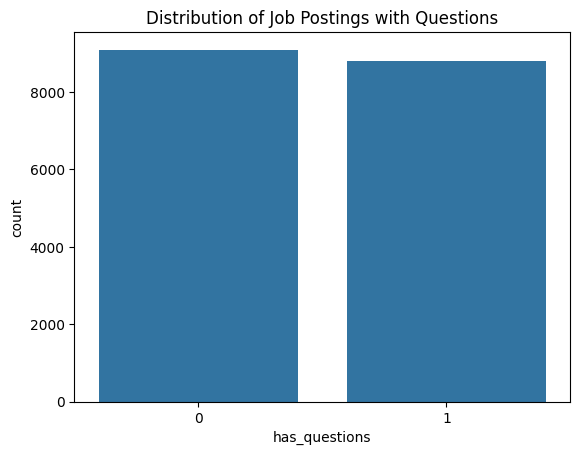

In [174]:
print("\nHas Questions distribution:")
print(df['has_questions'].value_counts(normalize=True) * 100)

sns.countplot(x=df['has_questions'])
plt.title('Distribution of Job Postings with Questions')
plt.show()

Roughly even split in whether screening questions are present in the job posting.


Fraudulent distribution:
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


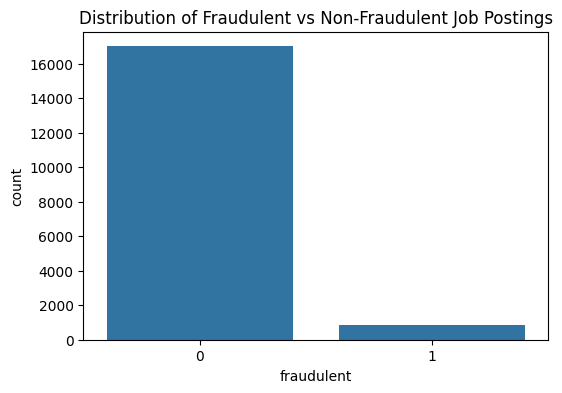

In [175]:
print("\nFraudulent distribution:")
print(df['fraudulent'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x='fraudulent',data=df)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Job Postings')
plt.show()

majority of all jobs are not fradulent

### Categorical Column Analysis

Analyze how different categories in each column lead to proportions of job postings to be fradulent or not.

Serves to capture relationships on where certain types of categories have a larger percentage of fraduluent job postings.

In [176]:
# df['benefits'] = df['benefits'].replace('na', np.nan)
# df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
# str_cols =  ['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
# num_cols = ['job_id', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']
# text_cols = ['company_profile', 'description', 'requirements', 'benefits']
# cat_cols = ['location', 'employment_type', 'required_experience', 
#             'required_education', 'industry', 'function']
# binary_cols = ['telecommuting', 'has_company_logo', 'has_questions']
# target = 'fraudulent'
# to_drop = ['job_id', 'department', 'salary_range']

# df[text_cols] = df[text_cols].fillna('')
# df[cat_cols] = df[cat_cols].fillna('Not Provided')

# df.isnull().sum()

In [177]:
print(f"Number of employment types: {df['employment_type'].value_counts().size}")

Number of employment types: 6


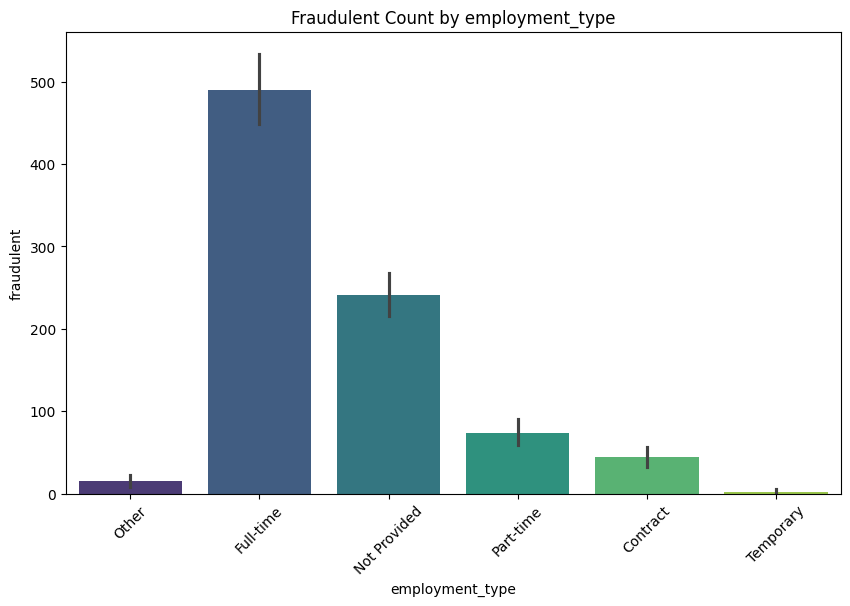

In [178]:
## Comapre employment type distribution for fraudulent job postings

plt.figure(figsize=(10,6))
sns.barplot(x='employment_type', y='fraudulent', data=df, palette='viridis',estimator=sum)
plt.title(f'Fraudulent Count by employment_type')
plt.xticks(rotation=45)
plt.show()

Majority of fraudulent job postings are for full time positions.

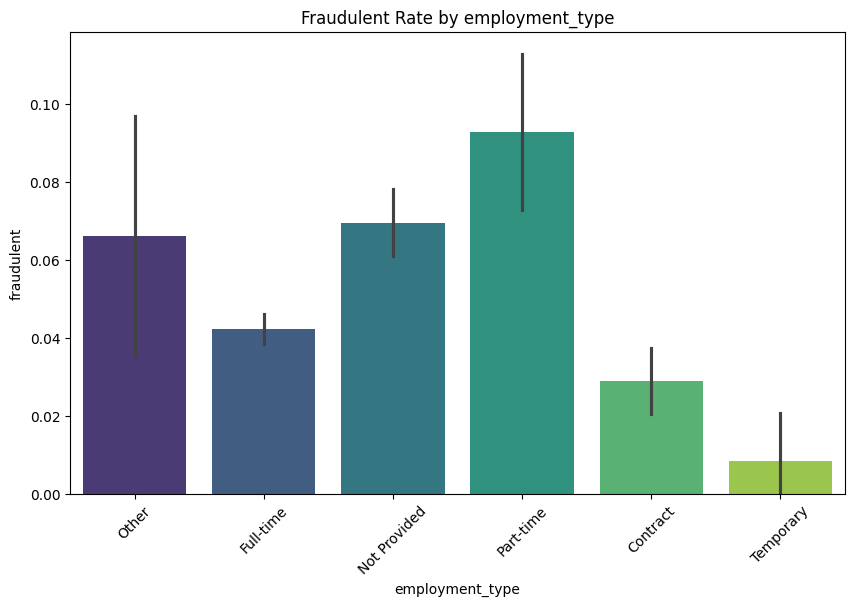

In [179]:
plt.figure(figsize=(10,6))
sns.barplot(x='employment_type', y='fraudulent', data=df, palette='viridis')
plt.title(f'Fraudulent Rate by employment_type')
plt.xticks(rotation=45)
plt.show()

However, we see that part-time job postings have the greatest proportion of fraudulent job postings. Thus, we see that while there are definitely more fake job postings of full time positions overall, part time positions have a higher rate of being fraudulent.

In [180]:
print(f"Number of required experience levels: {df['required_experience'].value_counts().size}")

Number of required experience levels: 8


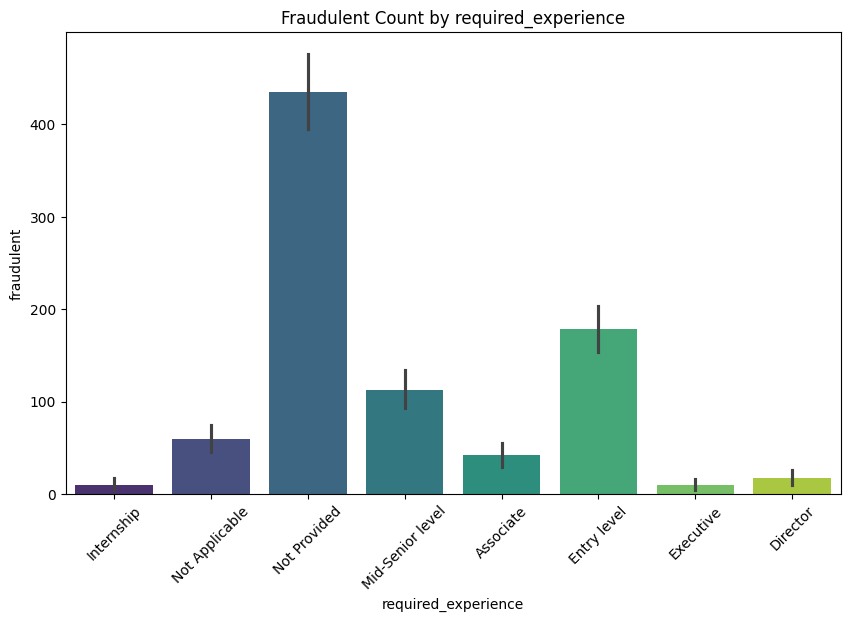

In [181]:
## Comapre required_experience distribution for fraudulent job postings

plt.figure(figsize=(10,6))
sns.barplot(x='required_experience', y='fraudulent', data=df, palette='viridis',estimator=sum)
plt.title(f'Fraudulent Count by required_experience')
plt.xticks(rotation=45)
plt.show()

Majority of the job postings that do not highlight a required experience are fraudulent.

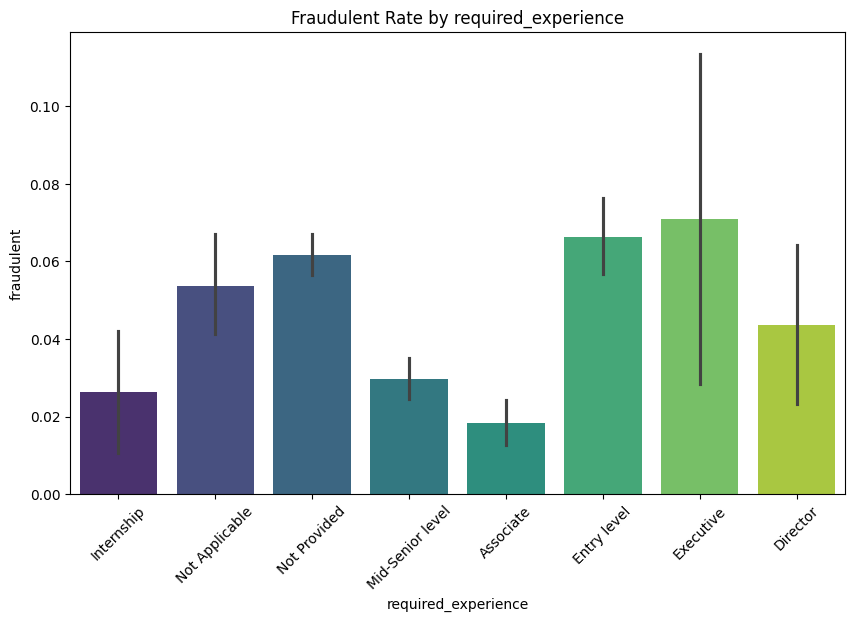

In [182]:
plt.figure(figsize=(10,6))
sns.barplot(x='required_experience', y='fraudulent', data=df, palette='viridis')
plt.title(f'Fraudulent Rate by required_experience')
plt.xticks(rotation=45)
plt.show()

However, majority of executive job postings are seen to have a higher percentage of fraudulent postings.

In [183]:
print(f"Number of required education levels: {df['required_education'].value_counts().size}")

Number of required education levels: 14


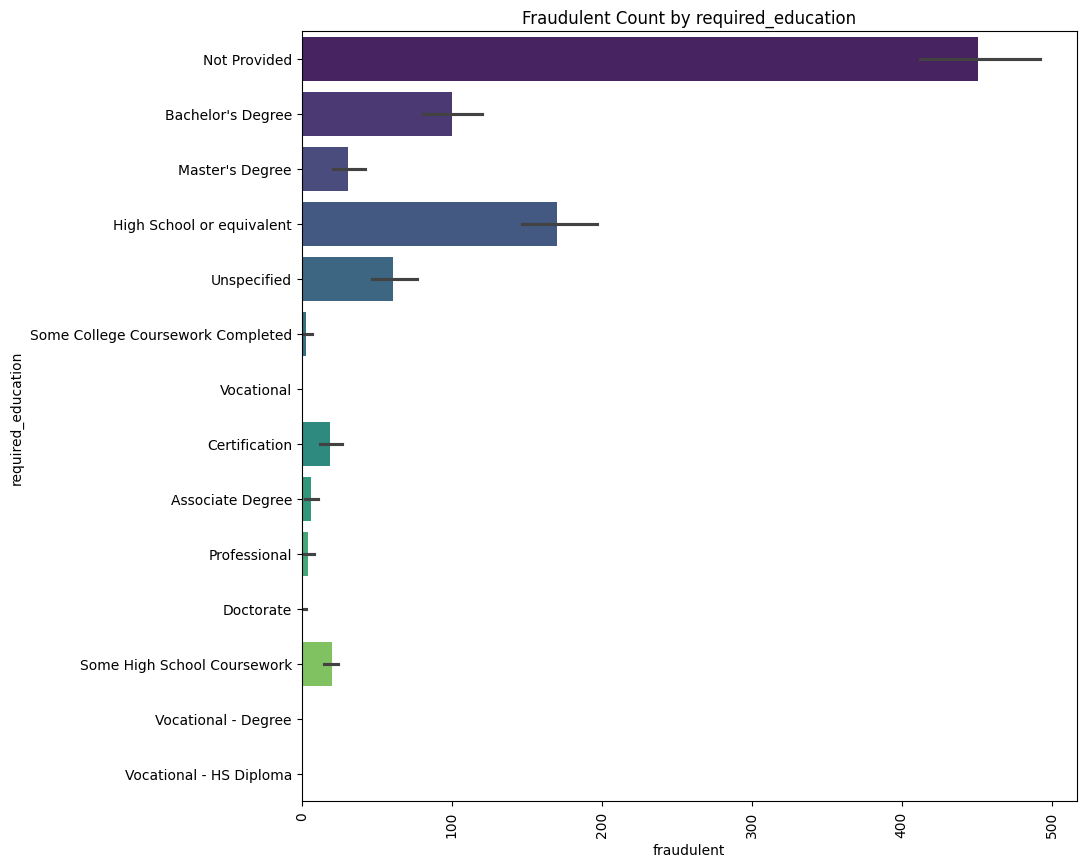

In [184]:
## Compare required_education distribution for fraudulent job postings
plt.figure(figsize=(10,10))
sns.barplot(y='required_education', x='fraudulent', data=df, palette='viridis',estimator=sum)
plt.title(f'Fraudulent Count by required_education')
plt.xticks(rotation=90)
plt.show()

Majority of fraudulent postings do not have a specified education.

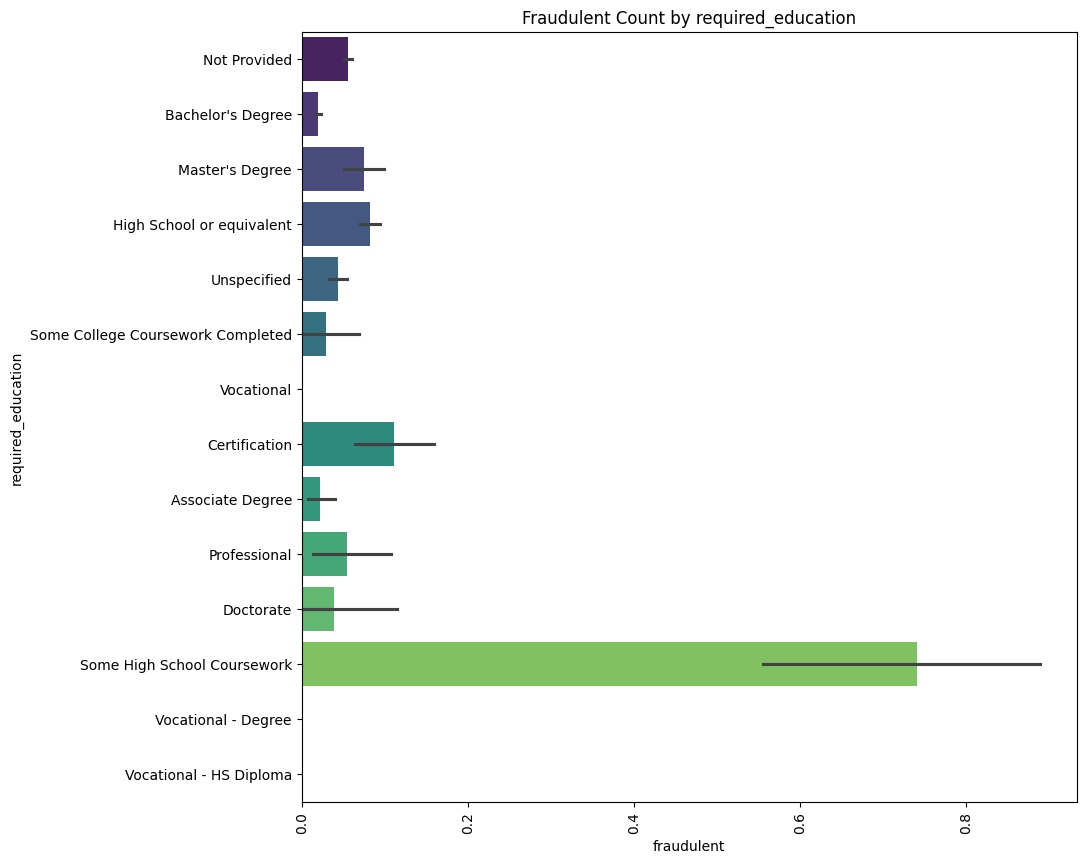

In [185]:
plt.figure(figsize=(10,10))
sns.barplot(y='required_education', x='fraudulent', data=df, palette='viridis')
plt.title(f'Fraudulent Count by required_education')
plt.xticks(rotation=90)
plt.show()

However, a significant proportion of job postings that only required high school education are considered fraudulent.

In [186]:
print(f"Number of functions: {df['function'].value_counts().size}")

Number of functions: 38


38 function categories

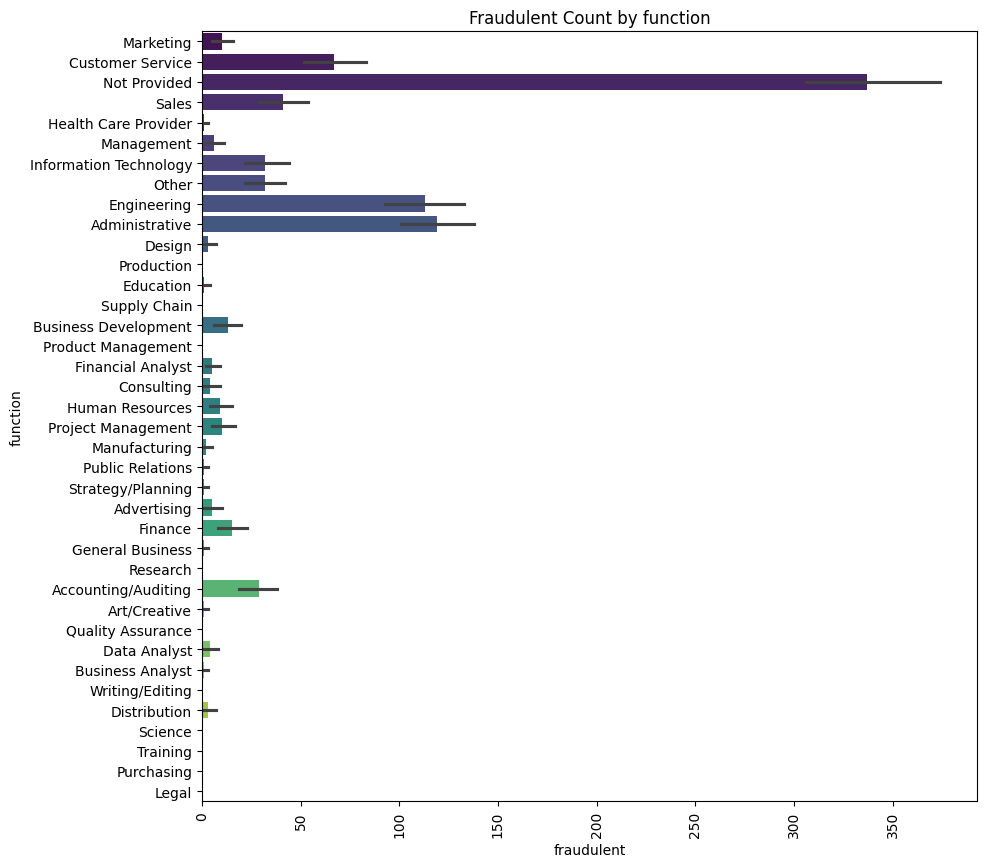

In [187]:
## function distribution for fraudulent job postings
plt.figure(figsize=(10,10))
sns.barplot(y='function', x='fraudulent', data=df, palette='viridis',estimator=sum)
plt.title(f'Fraudulent Count by function')
plt.xticks(rotation=90)
plt.show()

Majority of fraudulent postings do not have a specified function

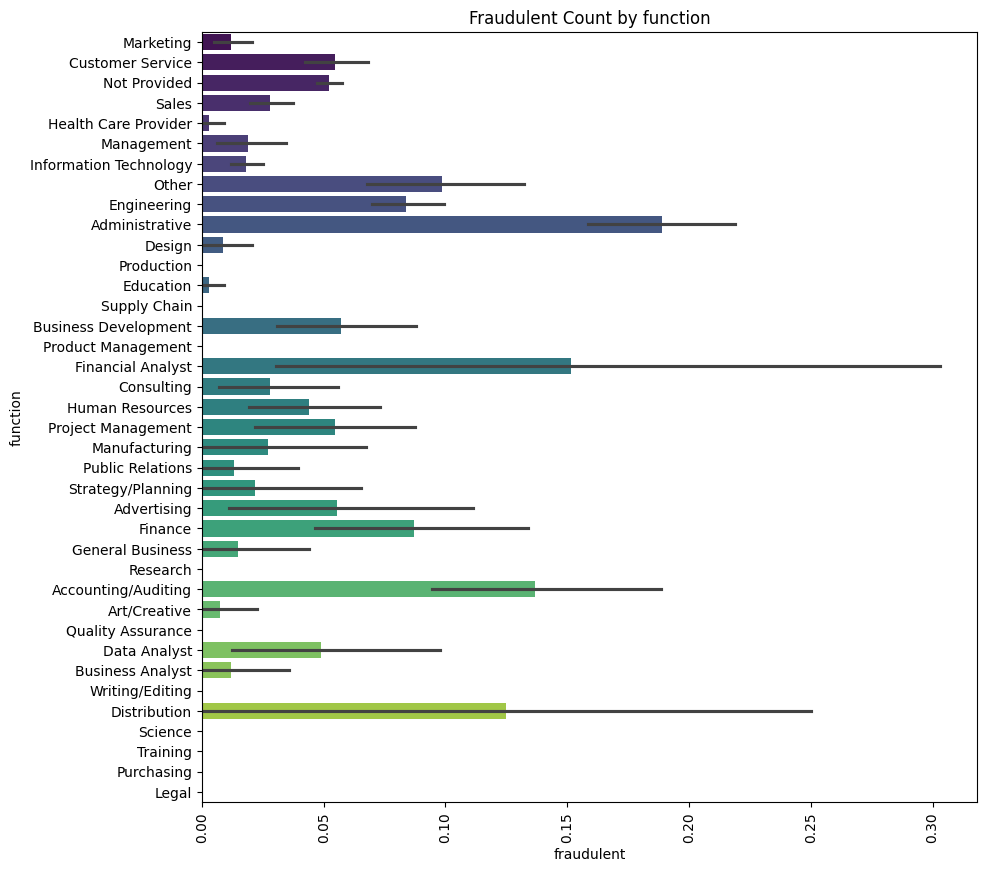

In [188]:
plt.figure(figsize=(10,10))
sns.barplot(y='function', x='fraudulent', data=df, palette='viridis')
plt.title(f'Fraudulent Count by function')
plt.xticks(rotation=90)
plt.show()

However, administraive functions have the highest proportion of fraudulent job postings.

In [189]:
print(f"Number of industries: {df['industry'].value_counts().size}")

Number of industries: 132


In [ ]:
# Calculate fraud rate per industry
ind_fraud = df.groupby('industry')['fraudulent'].mean().sort_values(ascending=False)

# Filter for industries that actually have a significant number of postings (e.g., > 50)
popular_industries = df['industry'].value_counts()
high_volume_ind = popular_industries[popular_industries > 50].index

print(ind_fraud[high_volume_ind].head(10)) # Plot only the high-volume, high-risk industries

industry
Not Provided                           0.056088
Information Technology and Services    0.018454
Computer Software                      0.003634
Internet                               0.000000
Marketing and Advertising              0.054348
Education Management                   0.000000
Financial Services                     0.044929
Hospital & Health Care                 0.102616
Consumer Services                      0.067039
Telecommunications                     0.076023
Name: fraudulent, dtype: float64


In [190]:
print(f"No. of Countries: {df['country'].value_counts().size}")

print(f"No. of States: {df['state'].value_counts().size}")

print(f"No. of Cities: {df['city'].value_counts().size}")

No. of Countries: 91
No. of States: 325
No. of Cities: 2388


In [204]:
df['city'].value_counts().head(10)

city
                 1627
London           1060
New York          669
Athens            542
San Francisco     477
Houston           271
Berlin            262
Chicago           257
Washington        255
Auckland          227
Name: count, dtype: int64

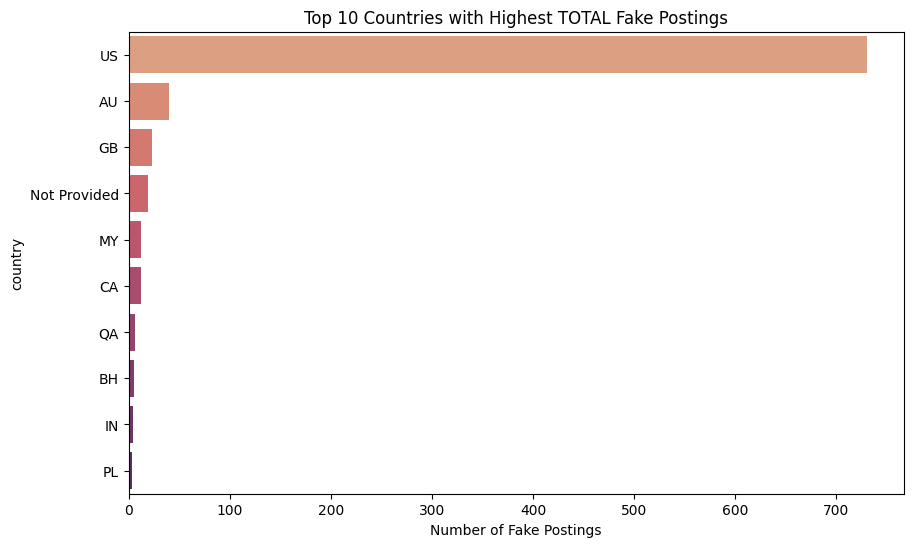

In [203]:
top_fraud_countries = df[df['fraudulent'] == 1]['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_fraud_countries.values, y=top_fraud_countries.index, palette='flare')
plt.title('Top 10 Countries with Highest TOTAL Fake Postings')
plt.xlabel('Number of Fake Postings')
plt.show()

In [206]:
# Check if BOTH State and City are missing
df['vague_location'] = (df['state'].isna()) & (df['city'].isna())
df['vague_location'] = df['vague_location'].astype(int)

# Check the Fraud Rate
vague_rate = df.groupby('vague_location')['fraudulent'].mean()
print("Fraud Rate: Vague (1) vs Specific (0) Locations:")
print(vague_rate)

Fraud Rate: Vague (1) vs Specific (0) Locations:
vague_location
0    0.048108
1    0.061364
Name: fraudulent, dtype: float64


### Free Text-based column analaysis

Preprocess the texts by removing common punctuations via Regex and common stop words to prevent miscalculation on the importance of seen words.

Use word cloud to give a basic visualisation of the spread of the words in the free text.

Use TF-IDF to give statistics on the contextual importance of the words used in these free text.



In [191]:
df['title'].head(10)

0                             Marketing Intern
1    Customer Service - Cloud Video Production
2      Commissioning Machinery Assistant (CMA)
3            Account Executive - Washington DC
4                          Bill Review Manager
5                             Accounting Clerk
6                        Head of Content (m/f)
7             Lead Guest Service Specialist   
8                                   HP BSM SME
9      Customer Service Associate - Part Time 
Name: title, dtype: object

In [192]:
## TODO: Preprocessing text columns for word cloud

In [193]:
def plot_wordcloud(text_data,title,color):
    
    combined_text = " ".join(text_data)
    wc =  WordCloud(
        width=800,
        height=400,
        colormap=color,
    ).generate(combined_text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis("off")
    plt.show()

In [194]:
fake_job_titles = df[df['fraudulent'] == 1]['title']
real_job_titles = df[df['fraudulent'] == 0]['title']

fake_job_profile = df[df['fraudulent'] == 1]['company_profile']
real_job_profile = df[df['fraudulent'] == 0]['company_profile']

fake_job_description = df[df['fraudulent'] == 1]['description']
real_job_description = df[df['fraudulent'] == 0]['description']

fake_job_requirements = df[df['fraudulent'] == 1]['requirements']
real_job_requirements = df[df['fraudulent'] == 0]['requirements']

fake_job_benefits = df[df['fraudulent'] == 1]['benefits']
real_job_benefits = df[df['fraudulent'] == 0]['benefits']

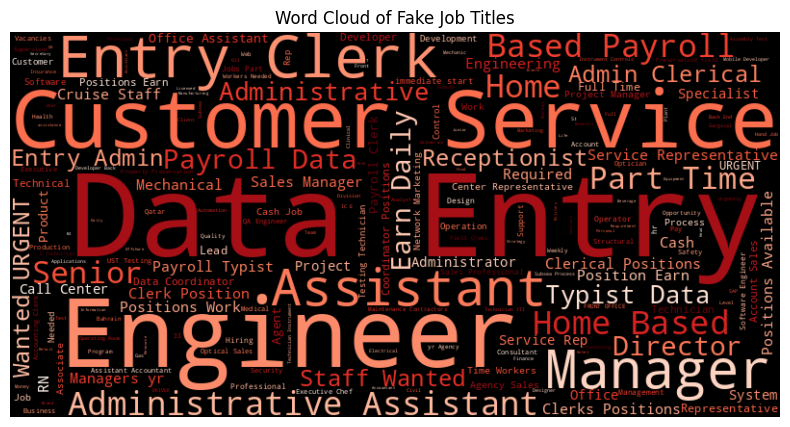

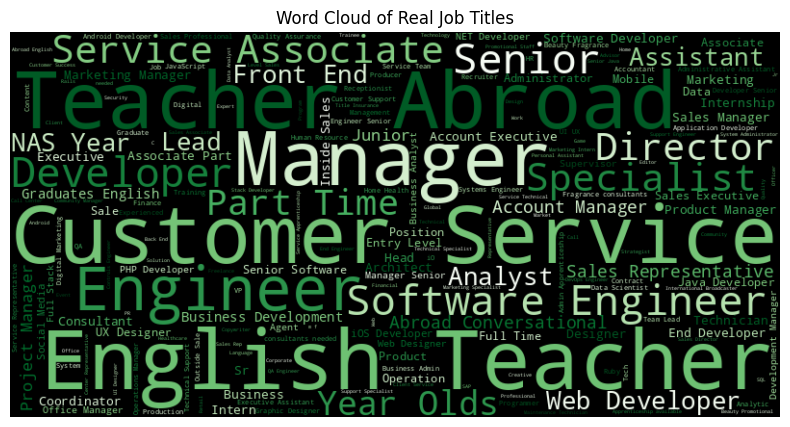

In [195]:
plot_wordcloud(fake_job_titles, 'Word Cloud of Fake Job Titles',"Reds")

plot_wordcloud(real_job_titles, 'Word Cloud of Real Job Titles',"Greens")

# df['title'].head()
# text = " ".join(title for title in df.title)
# wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text)
# plt.figure()
# plt.imshow(wordcloud, interpolation="bilinear")
# plt.axis("off")
# plt.show()

In [196]:
## TODO: Create word clouds for other text columns like description, requirements, benefits, etc.

In [197]:
## TODO: Implement a TF-IDF based word cloud to highlight more unique terms in fake vs real job postings

### Feature Engineering 

This section serves to engineer new features to discover relationships through the interactions between features.